# Лабораторная работа 6

Тема: **Оптимизация и скорость сходимости: шаг обучения и выбор оптимизатора**  
Цель: на одной и той же модели и датасете (MNIST + простой MLP) **экспериментально** исследовать, как ведут себя разные значения `learning_rate` и разные оптимизаторы (SGD, SGD+Momentum, Adam), и сформулировать свои практические правила выбора.

> Этот ноутбук предназначен именно для вашей самостоятельной работы.  
> Его структура и код — каркас, а содержание (графики, комментарии, выводы) должны отражать **ваши эксперименты и ваш стиль объяснения**.
> Если вы попытаетесь автоматически сгенерировать текст целиком, это будет заметно по общей, оторванной от ваших графиков формулировке.


## 1. Ваши ожидания до экспериментов

Прежде чем смотреть на реальные кривые, зафиксируйте, что вы **ожидаете** увидеть.

Ответьте своими словами:
1. Что, по вашему интуитивному ощущению, происходит с обучением при **очень маленьком** шаге (`lr`): по loss, по времени сходимости, по точности?  
2. Что может пойти не так при **слишком большом** шаге (`lr`), если смотреть на графики loss/accuracy?  
3. Чем вы ожидаете, что будет отличаться поведение **SGD**, **SGD с momentum** и **Adam** на задаче вроде MNIST (скорость сходимости, чувствительность к выбору lr, «рывки» на графиках и т.п.)?

Напишите ответы в свободной форме (6–10 предложений). Важно, чтобы это были именно ваши формулировки, а не пересказ учебника.


In [ ]:
expectations_text = """
1. При маленьком lr модель будет обучаться очень медленно - loss будет падать,
но очень постепенно. За 10 эпох она может просто не успеть сойтись до хорошей
точности. Это как идти к цели маленькими шажками -придёшь, но нескоро.

2. При слишком большом lr loss будет прыгать вверх-вниз и не сходиться.
Модель будет "перепрыгивать" через минимум туда-сюда. На графике это выглядит
как хаотичные скачки вместо плавного снижения. В худшем случае loss вообще
начнёт расти.

3. SGD без momentum будет сходиться медленно и нестабильно, особенно если lr
подобран не идеально. SGD с momentum должен быть быстрее и плавнее потому что
он как бы "разгоняется" в нужном направлении и не так сильно реагирует на
отдельные шумные батчи. Adam скорее всего покажет себя лучше всех с дефолтными
настройками потому что сам адаптирует шаг для каждого параметра. Мне не до
конца понятно насколько сильно будет видна разница на такой простой задаче
как MNIST.
"""
print(expectations_text)

## 2. Импорт библиотек и настройка среды

Здесь всё стандартно:
- импорт PyTorch, torchvision и вспомогательных библиотек;
- фиксация `seed` (одно число, которое вы сможете назвать на защите);
- определение устройства (`cpu` или `cuda`).


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# ВАШ ЛИЧНЫЙ SEED (можете выбрать любое число, но потом не меняйте его без причины)
MY_SEED = 13
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 13


## 3. Данные MNIST и DataLoader

Используем набор рукописных цифр MNIST.  
Ваша задача:
- задать трансформации (как минимум `ToTensor` + нормализация);
- загрузить обучающую и тестовую части;
- создать `DataLoader` с разумным `batch_size`.

Размер батча вы выбираете сами (например, 64 или 128), главное потом объяснить выбор по-человечески: чем он удобен именно для этой работы.


100%|██████████| 9.91M/9.91M [00:00<00:00, 13.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 349kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


train size = 60000
test size  = 10000
batch_size = 128


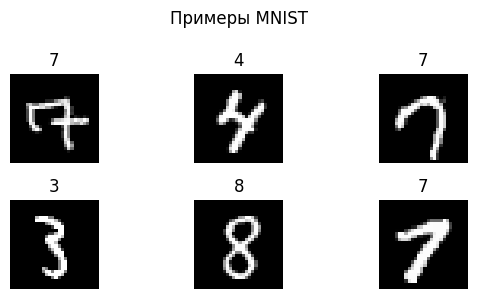

In [2]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print("train size =", len(train_dataset))
print("test size  =", len(test_dataset))
print("batch_size =", batch_size)

# быстрая визуальная проверка
images, labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"{labels[i].item()}")
    plt.axis("off")
plt.suptitle("Примеры MNIST")
plt.tight_layout()
plt.show()

Если вы хотите для спокойствия посмотреть на пару примеров изображений — можете добавить сюда небольшой блок визуализации (по образцу ЛР4–5). Это не обязательно, но иногда помогает ощутить задачу глазами.


## 4. Модель (фиксированная для всех экспериментов)

Чтобы сравнение оптимизаторов и `learning_rate` было честным, архитектура модели должна оставаться **одна и та же** во всех прогонах.

Возьмём простой MLP:
- вход: 28×28 → разворачиваем в вектор длины 784;
- два скрытых слоя с ReLU (например, 256 и 128 нейронов);
- выход: 10 логитов (по одному на цифру 0–9).

Эту архитектуру **не меняем** в рамках лабораторной (если измените — **обязательно явно зафиксируйте это в отчёте**).


In [3]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

print(SimpleMLP())

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


## 5. Общие функции обучения и оценки

Напишем функции `train_one_epoch` и `evaluate`.  
Их вы использовали в прошлых работах; сейчас они понадобятся, чтобы собирать **историю** обучения для разных конфигураций.


In [4]:
import time

criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0
    start = time.time()

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_time = time.time() - start
    return running_loss / total, running_correct / total, epoch_time


def evaluate(model, dataloader, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    return running_loss / total, running_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 6. Универсальная функция запуска одного эксперимента

Чтобы не копировать один и тот же код для разных настроек, напишем функцию `run_experiment`, которая:
- создаёт новую модель `SimpleMLP`;
- инициализирует оптимизатор (SGD / SGD+Momentum / Adam) с нужными параметрами;
- обучает модель `num_epochs` эпох;
- возвращает историю значений `train_loss`, `train_acc`, `test_loss`, `test_acc`.

Такой формат удобно использовать для честного сравнения разных конфигураций.


In [5]:
def run_experiment(config_name, optimizer_class, optimizer_kwargs,
                   num_epochs=10):
    print("\n=== Конфигурация:", config_name, "===")

    model = SimpleMLP().to(device)
    optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    total_time = 0.0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc, epoch_time = train_one_epoch(model, train_loader, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, device)
        total_time += epoch_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Эпоха {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f} | "
              f"время={epoch_time:.1f}с")

    print(f"Общее время: {total_time:.1f}с")
    return history

print("Функция run_experiment готова.")

Функция run_experiment готова.


## 7. Набор конфигураций для сравнения

Рекомендуемый набор (можете расширить):

- `SGD lr=0.001` — заведомо небольшой шаг;  
- `SGD lr=0.01` — разумный кандидат;  
- `SGD lr=0.5` — намеренно большой шаг, чтобы увидеть нестабильность;  
- `SGD lr=0.01, momentum=0.9` — добавляем momentum и смотрим, что изменится;  
- `Adam lr=0.001` — «типичная» настройка для Adam.

Число эпох выберите так, чтобы кривые успели чуть-чуть «устаканиться» (например, 8–12 эпох).


In [6]:
num_epochs = 10

histories = []
labels = []

# 1. SGD с маленьким шагом
h_sgd_small = run_experiment(
    config_name="SGD lr=0.001",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_sgd_small)
labels.append("SGD 0.001")

# 2. SGD с разумным шагом
h_sgd_mid = run_experiment(
    config_name="SGD lr=0.01",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01},
    num_epochs=num_epochs
)
histories.append(h_sgd_mid)
labels.append("SGD 0.01")

# 3. SGD с большим шагом
h_sgd_big = run_experiment(
    config_name="SGD lr=0.5",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.5},
    num_epochs=num_epochs
)
histories.append(h_sgd_big)
labels.append("SGD 0.5")

# 4. SGD с momentum
h_sgdm = run_experiment(
    config_name="SGD lr=0.01, momentum=0.9",
    optimizer_class=torch.optim.SGD,
    optimizer_kwargs={"lr": 0.01, "momentum": 0.9},
    num_epochs=num_epochs
)
histories.append(h_sgdm)
labels.append("SGD+mom 0.01")

# 5. Adam
h_adam = run_experiment(
    config_name="Adam lr=0.001",
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={"lr": 0.001},
    num_epochs=num_epochs
)
histories.append(h_adam)
labels.append("Adam 0.001")

# 6. Свой вариант: Adam с lr=0.01. посмотрим что будет при большем шаге
h_adam_big = run_experiment(
    config_name="Adam lr=0.01",
    optimizer_class=torch.optim.Adam,
    optimizer_kwargs={"lr": 0.01},
    num_epochs=num_epochs
)
histories.append(h_adam_big)
labels.append("Adam 0.01")


=== Конфигурация: SGD lr=0.001 ===
Эпоха 1/10 | train_loss=2.2104, train_acc=0.3919, test_loss=2.1088, test_acc=0.6072 | время=17.3с
Эпоха 2/10 | train_loss=1.9769, train_acc=0.6707, test_loss=1.8009, test_acc=0.7151 | время=16.9с
Эпоха 3/10 | train_loss=1.6032, train_acc=0.7325, test_loss=1.3646, test_acc=0.7674 | время=17.0с
Эпоха 4/10 | train_loss=1.1879, train_acc=0.7803, test_loss=0.9939, test_acc=0.8072 | время=16.9с
Эпоха 5/10 | train_loss=0.8953, train_acc=0.8163, test_loss=0.7727, test_acc=0.8352 | время=16.8с
Эпоха 6/10 | train_loss=0.7253, train_acc=0.8363, test_loss=0.6455, test_acc=0.8483 | время=16.8с
Эпоха 7/10 | train_loss=0.6231, train_acc=0.8499, test_loss=0.5653, test_acc=0.8616 | время=16.8с
Эпоха 8/10 | train_loss=0.5558, train_acc=0.8614, test_loss=0.5108, test_acc=0.8712 | время=16.9с
Эпоха 9/10 | train_loss=0.5084, train_acc=0.8691, test_loss=0.4712, test_acc=0.8795 | время=16.9с
Эпоха 10/10 | train_loss=0.4732, train_acc=0.8760, test_loss=0.4409, test_acc=0.88

## 8. Визуальное сравнение кривых для разных конфигураций

Теперь важно **на одном графике** увидеть, как ведут себя `train/test loss` и `train/test accuracy` для разных настроек.  
Это поможет сформировать интуицию, а не просто запомнить «Adam хороший, SGD плохой».


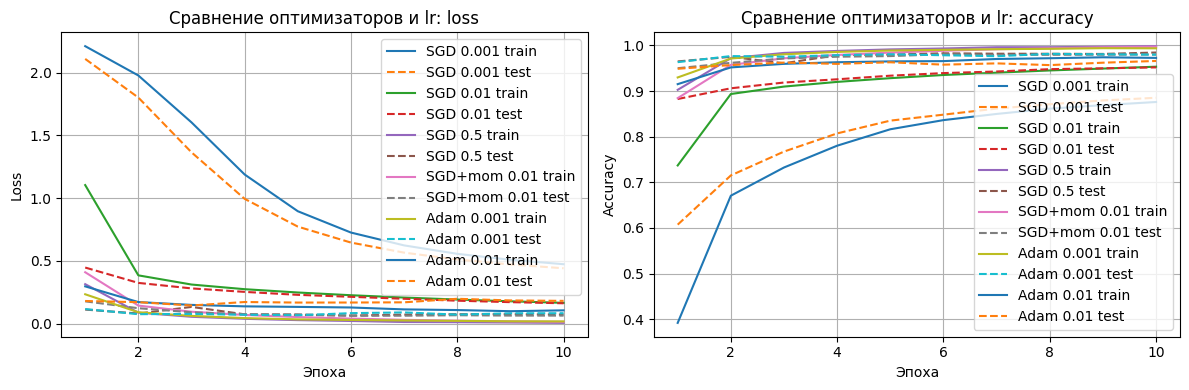

In [7]:
def plot_histories(histories, labels, title_prefix=""):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_loss"]) + 1)
        plt.plot(epochs, hist["train_loss"], label=f"{label} train")
        plt.plot(epochs, hist["test_loss"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title_prefix + "loss")
    plt.grid(True)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    for hist, label in zip(histories, labels):
        epochs = np.arange(1, len(hist["train_acc"]) + 1)
        plt.plot(epochs, hist["train_acc"], label=f"{label} train")
        plt.plot(epochs, hist["test_acc"], linestyle="--", label=f"{label} test")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title_prefix + "accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_histories(histories, labels, title_prefix="Сравнение оптимизаторов и lr: ")

## 9. Анализ результатов (самая важная часть)

Теперь нужно **словами** описать то, что вы увидели.  
Не переписывайте теорию про оптимизаторы — опирайтесь именно на свои графики и числа.

Попробуйте в одном связанном тексте ответить на такие вопросы:

- Как выглядели кривые для `SGD lr=0.001`: насколько медленно росла точность, успела ли она выйти на разумный уровень за `num_epochs`?  
- Что происходило при `SGD lr=0.5`: были ли скачки loss, «разброс» accuracy, признаки расходимости?  
- Как вёл себя `SGD lr=0.01`: показался ли вам этот шаг «рабочим компромиссом» между скоростью и стабильностью?  
- Что дал `momentum`: стало ли обучение более ровным/быстрым, изменилась ли финальная test accuracy по сравнению с чистым SGD?  
- Как отличался `Adam`: быстрее ли он выходил на высокую точность, как вёл себя test loss, было ли переобучение?

Упоминайте конкретные числа (например, test accuracy на последней эпохе для разных конфигураций) и форму кривых (плавные/рывковые, раннее насыщение и т. п.).


In [8]:
analysis_text = """
SGD lr=0.001 самый медленный из всех. За 10 эпох test_acc дошла только
до 0.885, при этом loss на первой эпохе был 2.21 - почти случайное угадывание.
Кривая плавная, без скачков, но за 10 эпох так и не вышла на нормальный уровень.
Ожидала медленного обучения - так и вышло.

SGD lr=0.5 удивил. Ожидала нестабильности и скачков, но модель сошлась
быстро и дала лучший результат - test_acc=0.984. Небольшой скачок test loss
между 2-й и 3-й эпохой есть, но в целом кривые ровные. На MNIST большой шаг
сработал лучше чем ожидала.

SGD lr=0.01 рабочий вариант, test_acc=0.952. Сходится стабильно, без
сюрпризов. Но по скорости заметно уступает SGD 0.5 - на 1-й эпохе всего 0.883
против 0.965.

SGD momentum=0.9 заметно лучше чем SGD 0.01 без momentum. Уже на 1-й эпохе
test_acc=0.950 против 0.883. Финальный результат 0.980 - momentum реально
разогнал обучение в начале и сгладил кривые.

Adam lr=0.001 быстро вышел на высокую точность (0.963 на 1-й эпохе), но
после 5-й эпохи test loss начал расти при падающем train loss - переобучение.
Финальный test_acc=0.980.

Adam lr=0.01 неожиданно плохо. Loss практически не падал после 3-й эпохи,
застрял на test_acc=0.966. Adam оказался чувствительнее к большому lr чем SGD.
"""
print(analysis_text)


SGD lr=0.001 самый медленный из всех. За 10 эпох test_acc дошла только
до 0.885, при этом loss на первой эпохе был 2.21 - почти случайное угадывание.
Кривая плавная, без скачков, но за 10 эпох так и не вышла на нормальный уровень.
Ожидала медленного обучения - так и вышло.

SGD lr=0.5 удивил. Ожидала нестабильности и скачков, но модель сошлась
быстро и дала лучший результат - test_acc=0.984. Небольшой скачок test loss
между 2-й и 3-й эпохой есть, но в целом кривые ровные. На MNIST большой шаг
сработал лучше чем ожидала.

SGD lr=0.01 рабочий вариант, test_acc=0.952. Сходится стабильно, без
сюрпризов. Но по скорости заметно уступает SGD 0.5 - на 1-й эпохе всего 0.883
против 0.965.

SGD momentum=0.9 заметно лучше чем SGD 0.01 без momentum. Уже на 1-й эпохе
test_acc=0.950 против 0.883. Финальный результат 0.980 - momentum реально
разогнал обучение в начале и сгладил кривые.

Adam lr=0.001 быстро вышел на высокую точность (0.963 на 1-й эпохе), но
после 5-й эпохи test loss начал расти при п

## 10. Итоговые практические выводы

В конце сформулируйте короткое резюме (5–8 предложений), как будто вы объясняете младшим курсам, **что вы вынесли из этой лабораторной**:

- Какие диапазоны `learning_rate` для SGD вы теперь считаете «слишком маленькими», «рабочими» и «слишком агрессивными» — именно на примере этой задачи.  
- В каких случаях вы бы использовали SGD с momentum, а в каких — достаточно обычного SGD.  
- Когда лично вы после этой работы предпочли бы Adam, а когда — всё-таки остались бы на SGD/SGD+Momentum (например, из-за понятности поведения, чувствительности к lr и т.п.).

Важно, чтобы здесь звучал ваш голос и ссылка на ваш опыт, а не абстрактные фразы про «Adam обычно лучше».


In [9]:
final_conclusion = """
По результатам экспериментов на MNIST с SimpleMLP:

lr=0.001 для SGD слишком мало, за 10 эпох не успевает выйти даже на 0.90.
lr=0.01 - рабочий, стабильный, но медленный. lr=0.5 агрессивный, но на
простых задачах сработал лучше всех. Значит граница "слишком много" сильно
зависит от задачи.

SGD с momentum стоит использовать почти всегда вместо чистого SGD - разница
заметна уже на первой эпохе (0.950 против 0.883 при том же lr=0.01), а
настраивать сложнее не становится.

Adam с lr=0.001 сошёлся быстро и стабильно, но начал переобучаться после
5-й эпохи. Adam с lr=0.01 показал себя хуже SGD 0.5 - то есть Adam не
всегда лучше, он просто менее чувствителен к выбору lr в разумном диапазоне.

Для себя запомню так: если хочется просто запустить и получить результат -
Adam lr=0.001. Если важно понять что происходит или задача простая - SGD с
momentum, там поведение более предсказуемое и легче заметить проблемы.
"""
print(final_conclusion)


По результатам экспериментов на MNIST с SimpleMLP:

lr=0.001 для SGD слишком мало, за 10 эпох не успевает выйти даже на 0.90.
lr=0.01 - рабочий, стабильный, но медленный. lr=0.5 агрессивный, но на
простых задачах сработал лучше всех. Значит граница "слишком много" сильно
зависит от задачи.

SGD с momentum стоит использовать почти всегда вместо чистого SGD - разница
заметна уже на первой эпохе (0.950 против 0.883 при том же lr=0.01), а
настраивать сложнее не становится.

Adam с lr=0.001 сошёлся быстро и стабильно, но начал переобучаться после
5-й эпохи. Adam с lr=0.01 показал себя хуже SGD 0.5 - то есть Adam не
всегда лучше, он просто менее чувствителен к выбору lr в разумном диапазоне.

Для себя запомню так: если хочется просто запустить и получить результат -
Adam lr=0.001. Если важно понять что происходит или задача простая - SGD с
momentum, там поведение более предсказуемое и легче заметить проблемы.

